













































# Lab 2: Logistic regression - Titanic

https://www.kaggle.com/c/titanic/data

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import os

In [2]:
import sklearn as sk

In [3]:
filename = 'titanic'

from urllib.request import urlretrieve
urlretrieve("https://bianchi.wp.imt.fr/files/2023/12/titanic.zip", filename + '.zip')

import os
zip_file = os.path.join(os.getcwd(), 'titanic.zip')

import zipfile
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(os.getcwd())

In [4]:
df = pd.read_csv("traintitanic.csv")


In [5]:
# Inspect the dataset
display(df.head())
display(df.describe(include="all"))
df.info()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.000000,891.000000,891.000000,891,891,714.000000,891.000000,891.000000,891,891.000000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Braund, Mr. Owen Harris",male,NaN,NaN,NaN,347082,NaN,B96 B98,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.000000,0.383838,2.308642,NaN,NaN,29.699118,0.523008,0.381594,NaN,32.204208,NaN,NaN
std,257.353842,0.486592,0.836071,NaN,NaN,14.526497,1.102743,0.806057,NaN,49.693429,NaN,NaN
min,1.000000,0.000000,1.000000,NaN,NaN,0.420000,0.000000,0.000000,NaN,0.000000,NaN,NaN
25%,223.500000,0.000000,2.000000,NaN,NaN,20.125000,0.000000,0.000000,NaN,7.910400,NaN,NaN
50%,446.000000,0.000000,3.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN
75%,668.500000,1.000000,3.000000,NaN,NaN,38.000000,1.000000,0.000000,NaN,31.000000,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
# Using the df.groupby("Pclass"), comment about the nature of the passengers as a function of the class ticket
# Average of the numerical features for each passenger class
df.groupby("Pclass").mean(numeric_only=True)


,PassengerId,Survived,Age,SibSp,Parch,Fare
Pclass,,,,,,
1,461.597222,0.629630,38.233441,0.416667,0.356481,84.154687
2,445.956522,0.472826,29.877630,0.402174,0.380435,20.662183
3,439.154786,0.242363,25.140620,0.615071,0.393075,13.675550


**Comment.** Higher classes carry clear privilege: 1st-class passengers are older on average (~38 vs ~25 in 3rd), paid far higher fares (~£84 vs ~£14), and survived much more often (63% vs 24%). `Pclass` is a strong proxy for wealth and deck location, both of which affected access to lifeboats.

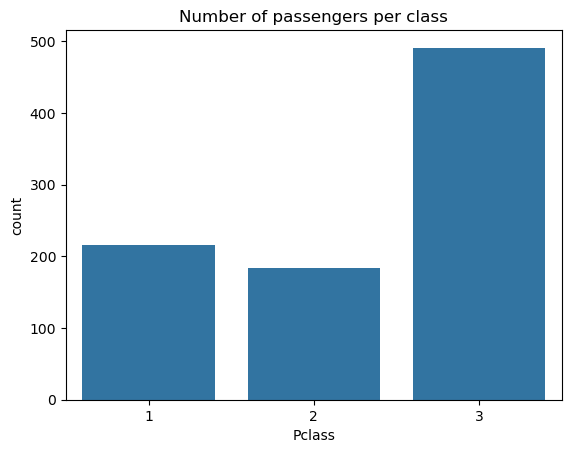

In [7]:
# Histogram (bar chart) of the passenger classes
sns.countplot(data=df, x="Pclass")
plt.title("Number of passengers per class")
plt.show()


Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64


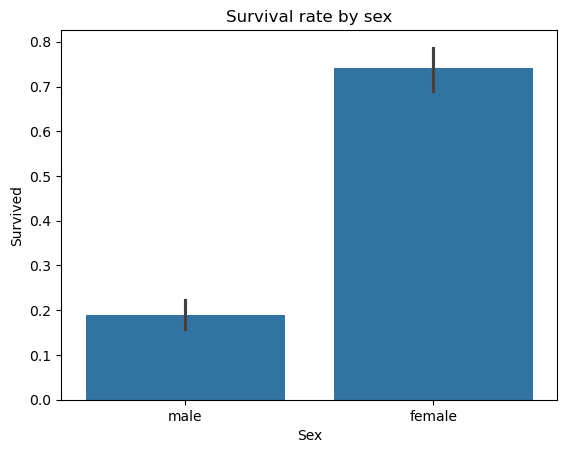

In [8]:
# Impact of the sex of passengers on survival
print(df.groupby("Sex")["Survived"].mean())
sns.barplot(data=df, x="Sex", y="Survived")
plt.title("Survival rate by sex")
plt.show()


Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64


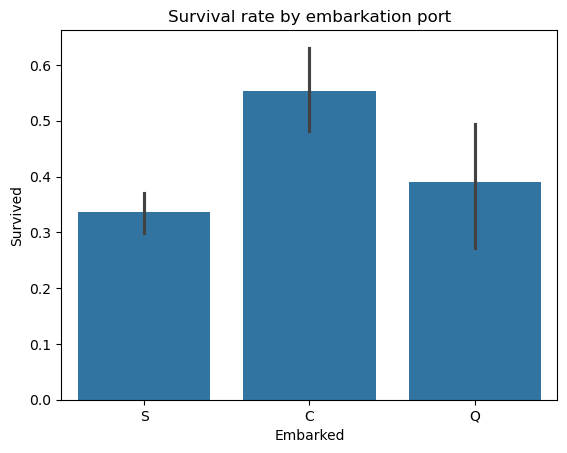

Pclass       1     2     3
Embarked                  
C         0.51  0.10  0.39
Q         0.03  0.04  0.94
S         0.20  0.25  0.55


In [9]:
# Impact of the embarkation city on survival
print(df.groupby("Embarked")["Survived"].mean())
sns.barplot(data=df, x="Embarked", y="Survived")
plt.title("Survival rate by embarkation port")
plt.show()

# Class composition of each port (helps explain the discrepancies)
print(pd.crosstab(df["Embarked"], df["Pclass"], normalize="index").round(2))


**Comment.** Survival by port is C (55%) > Q (39%) > S (34%). The gap is mostly a composition effect, not the port itself: passengers boarding at Cherbourg (C) were disproportionately 1st class (~51%), while Queenstown (Q) and Southampton (S) were dominated by 3rd-class passengers. Cherbourg's higher survival reflects its wealthier, higher-class mix.

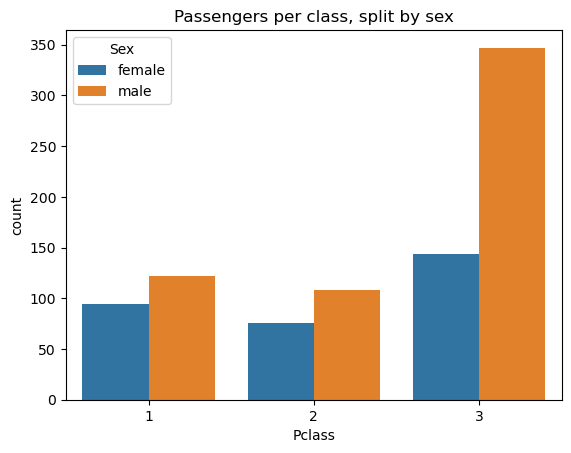

In [10]:
# Number of passengers of each sex within each class
sns.countplot(data=df, x="Pclass", hue="Sex")
plt.title("Passengers per class, split by sex")
plt.show()


**Comment.** Men outnumber women in every class, and the imbalance is largest in 3rd class. Combined with the very low male survival rate, this explains why most casualties were 3rd-class men.

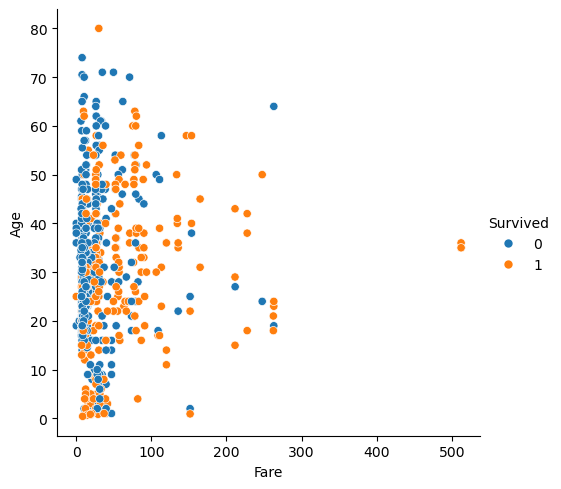

In [11]:
# Comment briefly the following code
sns.relplot(data=df,x="Fare", y="Age",hue="Survived")

**Comment.** `sns.relplot` draws a scatter plot of `Age` (y-axis) against `Fare` (x-axis), coloring each point by `Survived`. It lets us visually check whether fare/age relate to survival; survivors tend to cluster at higher fares.

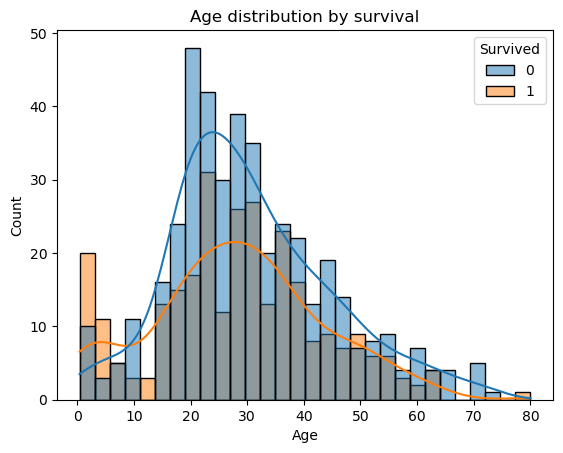

In [12]:
# Extra visualization: age distribution split by survival
sns.histplot(data=df, x="Age", hue="Survived", bins=30, kde=True)
plt.title("Age distribution by survival")
plt.show()


# Categorical encoding

Certain columns (sex, embarked, etc.) are categorical. We need to transform them into numerical features.

In [13]:
# Create a new column "Sex_num" where the strings "male" and "female" are replaced by a binary integer.
df["Sex_num"] = (df["Sex"]=="male").astype("int") #That's ok because there is no missing data in the "Sex" column

In [14]:
# What is the following code doing?
pd.get_dummies(df['Embarked'])

,C,Q,S
0,False,False,True
1,True,False,False
2,False,False,True
3,False,False,True
4,False,False,True
...,...,...,...
886,False,False,True
887,False,False,True
888,False,False,True
889,True,False,False


**Answer.** `pd.get_dummies` one-hot encodes the categorical `Embarked` column: it returns a table with one boolean column per port (C, Q, S), where each row has a 1 in the column of its embarkation port and 0 in the others.

In [15]:
# Using pd.get_dummies, create new columns in the dataframe df, one for each embarkation port
ports = pd.get_dummies(df['Embarked'])
for col in ports.columns:
    df[col] = ports[col].astype(int)
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Sex_num,C,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,1,0,0,1


In [16]:
# We may drop the two columns "Sex" and "Embarked", as we now included their onehot counterparts in the dataframe. Check that the following code drops theses columns
df.drop(columns=["Sex","Embarked"])

,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_num,C,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",27.0,0,0,211536,13.0000,NaN,1,0,0,1
887,888,1,1,"Graham, Miss. Margaret Edith",19.0,0,0,112053,30.0000,B42,0,0,0,1
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",NaN,1,2,W./C. 6607,23.4500,NaN,0,0,0,1
889,890,1,1,"Behr, Mr. Karl Howell",26.0,0,0,111369,30.0000,C148,1,1,0,0


In [17]:
# The previous cell did NOT modify df: drop() returns a copy unless inplace=True is used.
df.drop(columns=["Sex", "Embarked"], inplace=True)
df.head()


,PassengerId,Survived,Pclass,Name,Age,SibSp,Parch,Ticket,Fare,Cabin,Sex_num,C,Q,S
0,1,0,3,"Braund, Mr. Owen Harris",22.0,1,0,A/5 21171,7.2500,NaN,1,0,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",38.0,1,0,PC 17599,71.2833,C85,0,1,0,0
2,3,1,3,"Heikkinen, Miss. Laina",26.0,0,0,STON/O2. 3101282,7.9250,NaN,0,0,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",35.0,1,0,113803,53.1000,C123,0,0,0,1
4,5,0,3,"Allen, Mr. William Henry",35.0,0,0,373450,8.0500,NaN,1,0,0,1


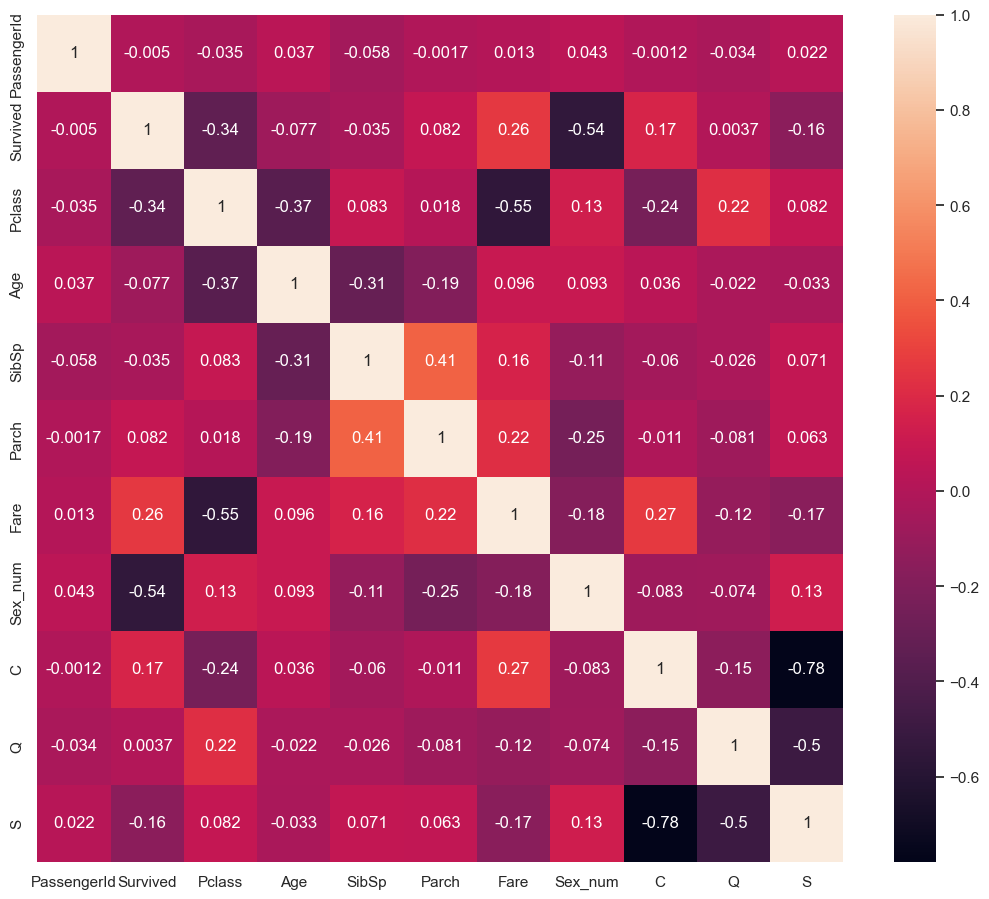

In [18]:
# df.corr() is the pairwise (Pearson) correlation matrix between numerical columns.
sns.set(rc = {'figure.figsize':(13,11)})
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()


**Interpretation.** `df.corr()` is the matrix of pairwise Pearson correlations (each in [-1, 1]) between numerical columns. Notably, `Survived` is negatively correlated with `Pclass` (lower class number = higher survival) and with `Sex_num` (males survive less), and positively with `Fare`. `Pclass` and `Fare` are strongly anti-correlated (1st class costs more). Correlation captures only linear association, not causation.

# Data cleansing
Check the number of missing values in "Age". You can either


*   Do nothing (the rows with missing "Age" will be ignored in the training stage)
*   Or fill the missing values with some value of your choice.


Do something smart.



In [19]:
# Smart imputation: fill missing ages with the median age of passengers sharing the
# same class and sex (a much better guess than a single global mean).
print("Missing ages before:", df["Age"].isna().sum())
df["Age"] = df.groupby(["Pclass", "Sex_num"])["Age"].transform(lambda s: s.fillna(s.median()))
print("Missing ages after :", df["Age"].isna().sum())


Missing ages before: 177
Missing ages after : 0


In [20]:
# Keep numerical / encoded features that plausibly affect survival.
# We drop Ticket and Cabin: Ticket is a high-cardinality identifier with no clean
# numeric meaning, and Cabin is missing for ~77% of passengers.
mycolumns = ["Pclass", "Age", "SibSp", "Parch", "Fare", "Sex_num", "C", "Q", "S"]


**Why not Ticket / Cabin?** `Ticket` is a high-cardinality, inconsistent identifier with no direct numeric meaning, and `Cabin` is missing for ~77% of passengers — too sparse to use reliably without heavy feature engineering.

# Logistic regression


In [21]:
# Train a logistic regression classifier using sklearn, based on the above dataframe and the chosen columns.
# Explain the meaning of the parameter in the logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(penalty='l2',C=1.0,max_iter=1000)

**Parameters.** `penalty='l2'` adds a ridge (sum of squared weights) penalty that discourages large coefficients; `C=1.0` is the inverse regularization strength (smaller C = stronger regularization); `max_iter=1000` caps the optimizer's iterations so it has enough steps to converge.

In [22]:
# Fit the model
X_train = df[mycolumns]
y_train = df["Survived"]
lr.fit(X_train, y_train)
print("Training accuracy:", lr.score(X_train, y_train))


Training accuracy: 0.8092031425364759


In [23]:
# Coefficients of the logistic regression (log-odds contribution of each feature)
coefs = pd.Series(lr.coef_[0], index=mycolumns).sort_values()
print(coefs)
print("\nIntercept:", lr.intercept_[0])


Sex_num   -2.594749
Pclass    -1.157698
SibSp     -0.335172
S         -0.289435
Parch     -0.074985
Age       -0.042722
Q         -0.034286
Fare       0.001912
C          0.090099
dtype: float64

Intercept: 5.291587187999206


Coefficients are log-odds contributions. `Sex_num` has a large negative coefficient (being male sharply lowers survival odds) and `Pclass` is negative (3rd class lowers odds) — consistent with the EDA. Higher `Fare` and the female/Cherbourg-related terms push survival up. The signs and magnitudes match intuition: women and higher-class passengers were more likely to survive.

# Performance evaluation


In [ ]:
# Load the test data
Xtest = pd.read_csv("testtitanic.csv")
ytest = pd.read_csv("gender_submission.csv")
dftest = pd.merge(Xtest,ytest)

In [25]:
# Process the test set exactly like the train set
dftest["Sex_num"] = (dftest["Sex"] == "male").astype(int)

ports_test = pd.get_dummies(dftest["Embarked"])
for col in ["C", "Q", "S"]:
    dftest[col] = ports_test.get(col, 0)
    dftest[col] = dftest[col].astype(int)

# Same smart age imputation as on the train set
dftest["Age"] = dftest.groupby(["Pclass", "Sex_num"])["Age"].transform(lambda s: s.fillna(s.median()))
dftest.head()


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Survived,Sex_num,C,Q,S
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q,0,1,0,1,0
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S,1,0,0,0,1
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q,0,1,0,1,0
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S,0,1,0,0,1
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S,1,0,0,0,1


In [26]:
# Define a dataframe with only the columns you want to keep (and the label)
dftest=dftest[mycolumns+["Survived"]]
dftest.head()

,Pclass,Age,SibSp,Parch,Fare,Sex_num,C,Q,S,Survived
0,3,34.5,0,0,7.8292,1,0,1,0,0
1,3,47.0,1,0,7.0000,0,0,0,1,1
2,2,62.0,0,0,9.6875,1,0,1,0,0
3,3,27.0,0,0,8.6625,1,0,0,1,0
4,3,22.0,1,1,12.2875,0,0,0,1,1


In [27]:
# Check for and drop any remaining missing values (e.g. a missing Fare in the test set)
print(dftest.isna().sum())
dftest.dropna(inplace=True)


Pclass      0
Age         0
SibSp       0
Parch       0
Fare        1
Sex_num     0
C           0
Q           0
S           0
Survived    0
dtype: int64


In [28]:
# Compute the hard predictions on the test set
Xtest_f = dftest[mycolumns]
ytest_f = dftest["Survived"]
ypred = lr.predict(Xtest_f)
ypred[:20]


array([0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0])

In [29]:
# Compute the accuracy score
from sklearn.metrics import accuracy_score
print("Test accuracy:", accuracy_score(ytest_f, ypred))


Test accuracy: 0.9280575539568345


In [30]:
# Compute the soft predictions (probability of survival) using predict_proba
yprob = lr.predict_proba(Xtest_f)[:, 1]
yprob[:10]


array([0.09368262, 0.30988484, 0.09253412, 0.0995156 , 0.55045609,
       0.16162884, 0.62647833, 0.20205944, 0.76013526, 0.06997852])

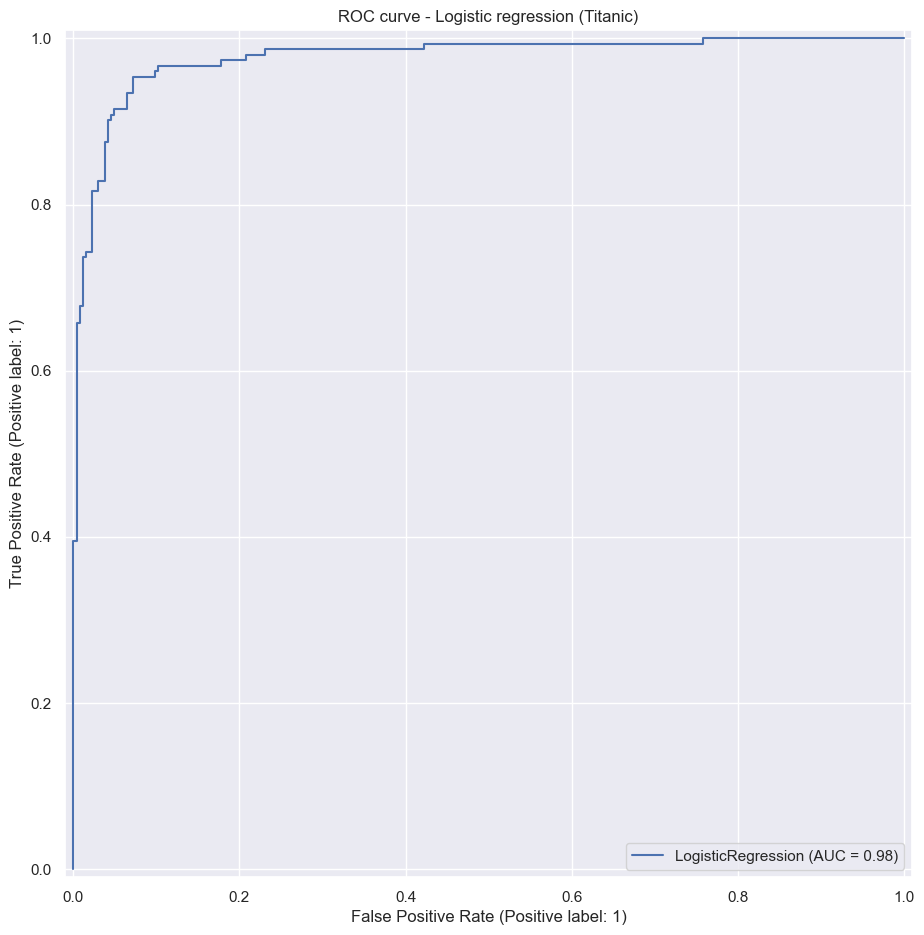

In [31]:
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_estimator(lr, Xtest_f, ytest_f)
plt.title("ROC curve - Logistic regression (Titanic)")
plt.show()


# Bonus question: do whatever you find useful

Here are some examples:

*   Try to include useful elements of the Cabin number
*   Try different regularization parameters
* Try L1 regularization instead of ridge
* Try linear regression





In [33]:
# Compare regularization choices (L2 vs L1, different C)
from sklearn.linear_model import LogisticRegression

for pen, C in [("l2", 1.0), ("l2", 0.1), ("l1", 1.0), ("l1", 0.1)]:
    m = LogisticRegression(penalty=pen, C=C, solver="liblinear", max_iter=1000)
    m.fit(X_train, y_train)
    acc = accuracy_score(ytest_f, m.predict(Xtest_f))
    print(f"penalty={pen}, C={C}: test accuracy = {acc:.3f}")


penalty=l2, C=1.0: test accuracy = 0.950
penalty=l2, C=0.1: test accuracy = 0.947
penalty=l1, C=1.0: test accuracy = 0.945
penalty=l1, C=0.1: test accuracy = 0.964
